# TCGA — Model Results & Interpretation

This notebook summarises all model results trained on the TCGA pan-cancer dataset:
- Binary classification: TP53 mutant vs wild-type
- Multiclass classification: mutation type (Missense, Nonsense, Frameshift, Splice, Other, WT)
- Advanced models: LightGBM multiclass and One-vs-Rest LightGBM

In [1]:
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.chdir(ROOT)

pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Binary Classification — TP53 Mutant vs Wild-Type

Best model selected on validation set, evaluated on held-out test set.

In [2]:
binary_test = pd.read_csv('reports/tables/tcga_binary_test_performance.csv')
binary_val  = pd.read_csv('reports/tables/tcga_binary_validation_performance.csv')

print('Best model:', binary_test['model'].iloc[0], '|', binary_test['feature_set'].iloc[0])
binary_test[['accuracy','balanced_accuracy','precision','recall','f1','roc_auc','pr_auc']]

Best model: hist_gradient_boosting | top_3000_variable


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.8640,0.8445,0.7894,0.7894,0.7894,0.9213,0.8185


In [3]:
# All models on validation set
binary_val.sort_values('roc_auc', ascending=False)[['feature_set','model','roc_auc','balanced_accuracy','f1']].head(10)

,feature_set,model,roc_auc,balanced_accuracy,f1
0,top_3000_variable,hist_gradient_boosting,0.9262,0.8391,0.7856
1,p53_pathway,extra_trees,0.9259,0.8493,0.7929
2,p53_pathway,random_forest,0.9247,0.8255,0.7664
3,top_3000_variable,mlp,0.9209,0.8425,0.7879
4,tp53_targets,extra_trees,0.9183,0.8365,0.7775
5,tp53_targets,random_forest,0.9159,0.8179,0.7578
6,p53_pathway,elastic_net_logistic,0.9103,0.8466,0.7735
7,p53_pathway,logistic_l2,0.9102,0.8440,0.7702
8,p53_pathway,linear_svm,0.9100,0.8452,0.7708
9,top_3000_variable,random_forest,0.9053,0.7990,0.7344


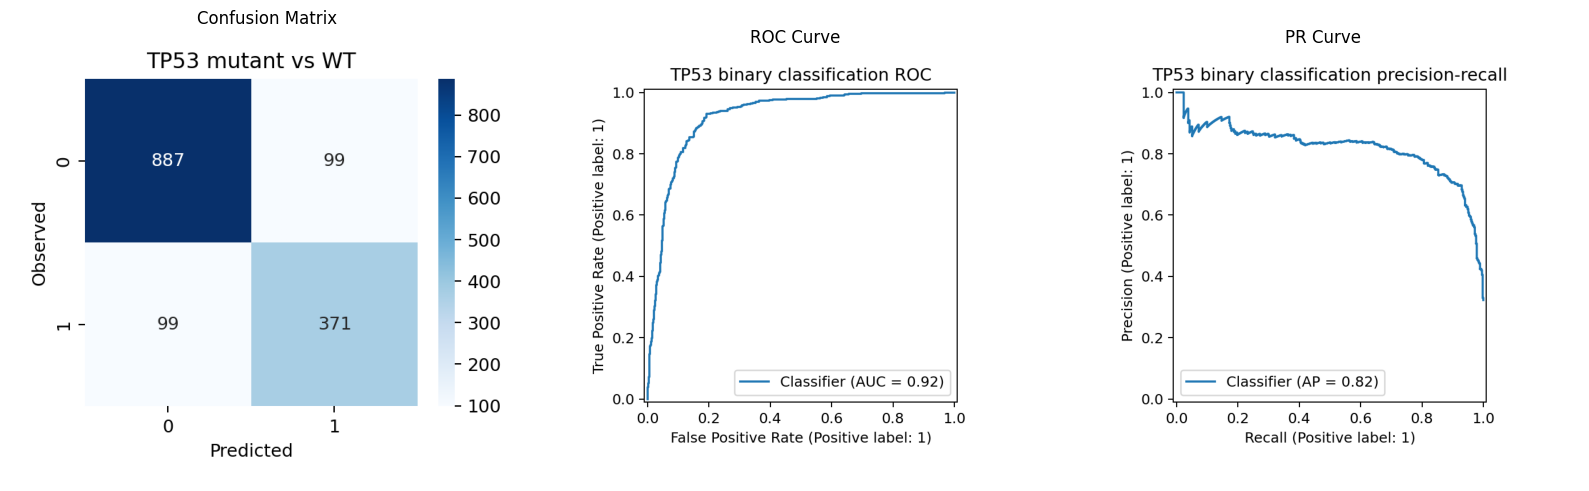

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, path, title in zip(axes,
    ['reports/figures/tcga_binary_confusion_matrix.png',
     'reports/figures/tcga_binary_best_model_roc.png',
     'reports/figures/tcga_binary_best_model_pr.png'],
    ['Confusion Matrix', 'ROC Curve', 'PR Curve']):
    ax.imshow(mpimg.imread(path))
    ax.axis('off')
    ax.set_title(title)
plt.tight_layout()
plt.show()

**Interpretation:**

The best binary model is a **Histogram Gradient Boosting classifier on the top 3,000 variable genes**, achieving ROC-AUC of **0.921** on the test set — better than the CCLE baseline (0.906). 
The larger and more diverse TCGA dataset provides a stronger transcriptional signal for separating mutant from wild-type.

The lower F1 (0.789 vs 0.863 on CCLE) reflects the reversed class balance in TCGA: 68% of samples are wild-type, making the model more conservative about predicting mutant. 
This is not a failure — the balanced accuracy (0.844) confirms the model is genuinely discriminating both classes well.

The PR curve (precision-recall) is more informative than ROC here given the class imbalance. A high PR-AUC means the model maintains good precision even at high recall thresholds.

## 2. Binary — Performance by Cancer Type

Does the model generalise across cancer lineages, or does it rely on lineage-specific patterns?

In [5]:
lineage = pd.read_csv('reports/tables/tcga_binary_per_lineage_performance.csv')
lineage = lineage.sort_values('balanced_accuracy', ascending=False)
lineage

,lineage,n,balanced_accuracy,f1
3,brain lower grade glioma,84,0.9643,0.9630
16,rectum adenocarcinoma,27,0.9250,0.9333
18,pancreatic adenocarcinoma,22,0.9060,0.9231
5,colon adenocarcinoma,80,0.8377,0.8000
12,liver hepatocellular carcinoma,53,0.8083,0.6000
19,glioblastoma multiforme,20,0.8000,0.6667
1,lung adenocarcinoma,87,0.7667,0.7917
4,uterine corpus endometrioid carcinoma,83,0.7662,0.6829
0,breast invasive carcinoma,175,0.7611,0.6341
2,head & neck squamous cell carcinoma,86,0.7468,0.8730


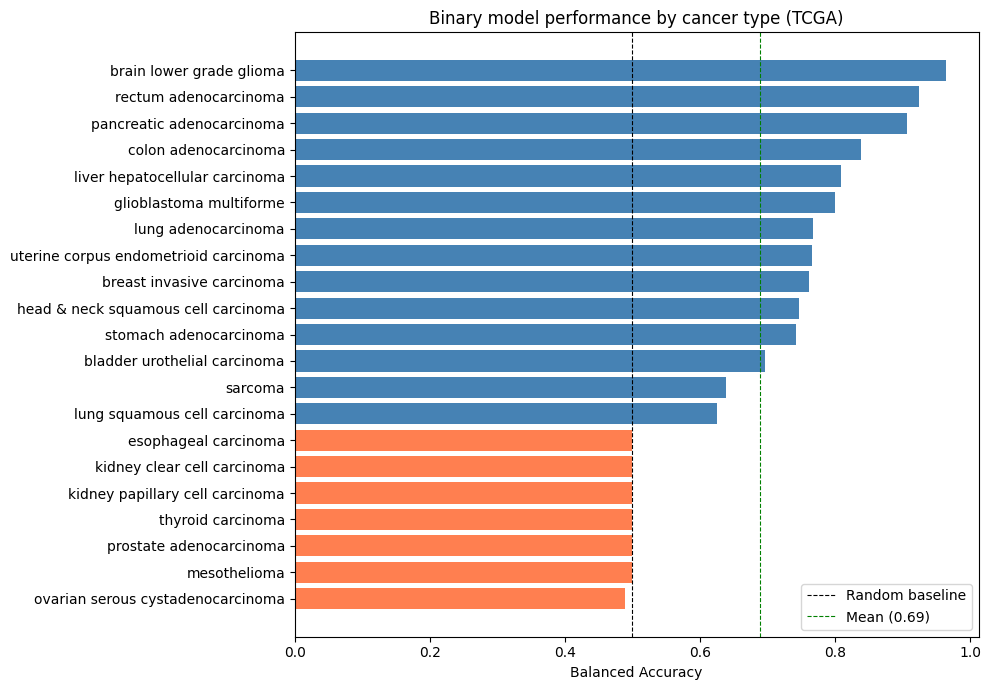

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['coral' if b < 0.6 else 'steelblue' for b in lineage['balanced_accuracy']]
ax.barh(lineage['lineage'], lineage['balanced_accuracy'], color=colors)
ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8, label='Random baseline')
ax.axvline(lineage['balanced_accuracy'].mean(), color='green', linestyle='--', linewidth=0.8, label=f'Mean ({lineage["balanced_accuracy"].mean():.2f})')
ax.set_xlabel('Balanced Accuracy')
ax.set_title('Binary model performance by cancer type (TCGA)')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretation:**

Performance varies substantially across cancer types. Several patterns stand out:

- **High performers** (balanced accuracy > 0.80): brain lower grade glioma, rectum adenocarcinoma, pancreatic adenocarcinoma — these cancers have strong TP53 transcriptional signatures or highly consistent mutation patterns.
- **Near-random** (balanced accuracy ≈ 0.50): prostate adenocarcinoma, thyroid carcinoma, kidney clear cell carcinoma, ovarian serous cystadenocarcinoma — these are likely cancers where either TP53 mutation rate is very low (model always predicts WT) or the transcriptional effect of TP53 mutation is weak.
- **Brain lower grade glioma** stands out with near-perfect performance (0.964) — consistent with the PCA where glioma formed its own distinct cluster, making TP53 status highly readable from expression.

This heterogeneity is the core limitation of pan-cancer modelling: a single model must generalise across cancers with very different biology.

## 3. Multiclass Classification — Mutation Type

Predicting the type of TP53 mutation: Missense, Nonsense, Frameshift, Splice, Other (and WT).

In [7]:
mc_test = pd.read_csv('reports/tables/tcga_multiclass_test_performance.csv')
mc_val  = pd.read_csv('reports/tables/tcga_multiclass_validation_performance.csv')

print('Best model:', mc_test['model'].iloc[0], '|', mc_test['feature_set'].iloc[0])
mc_test[['accuracy','balanced_accuracy','macro_f1','weighted_f1']]

Best model: linear_svm | p53_pathway


,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,0.7342,0.3834,0.3683,0.7448


In [8]:
mc_val.sort_values('macro_f1', ascending=False)[['feature_set','model','macro_f1','balanced_accuracy','weighted_f1']].head(10)

,feature_set,model,macro_f1,balanced_accuracy,weighted_f1
0,p53_pathway,linear_svm,0.3611,0.3814,0.7422
1,tp53_targets,mlp,0.3377,0.3348,0.7493
2,tp53_targets,extra_trees,0.3364,0.3304,0.7450
3,p53_pathway,logistic_l2,0.3362,0.3721,0.6790
4,tp53_targets,linear_svm,0.3357,0.3602,0.7170
5,p53_pathway,hist_gradient_boosting,0.3353,0.3285,0.7623
6,tp53_targets,hist_gradient_boosting,0.3348,0.3238,0.7492
7,tp53_targets,random_forest,0.3186,0.3110,0.7344
8,p53_pathway,extra_trees,0.3174,0.3108,0.7492
9,p53_pathway,random_forest,0.3150,0.3054,0.7394


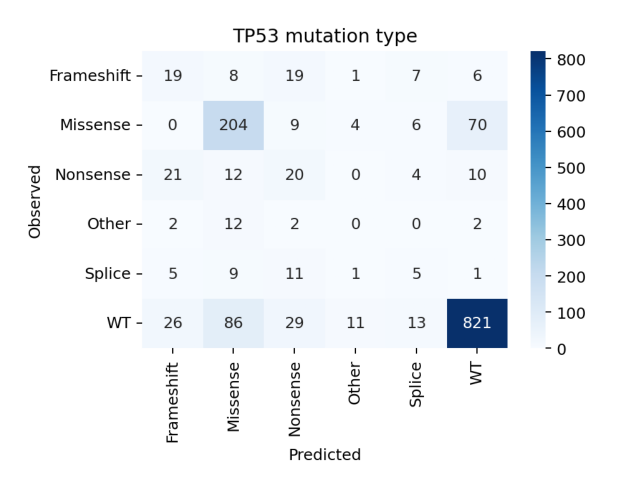

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(mpimg.imread('reports/figures/tcga_multiclass_confusion_matrix.png'))
ax.axis('off')
plt.tight_layout()
plt.show()

## Confusion Matrix Analysis — TCGA Multiclass Baseline

The confusion matrix reveals a clear two-tier structure in model performance driven by class size.

What the model gets right:

WT is predicted well — 821/986 correct (83% recall). As the dominant class (68% of all samples), the model has strong prior incentive to predict WT.
Missense achieves reasonable recall — 204/293 correct (70%). It is the largest mutation class and has the most examples to learn from.
What the model fails on:

Other: 0/18 correct (0% recall) — the model never successfully identifies this class. All samples are scattered across Missense and Frameshift predictions.
Splice: 5/32 correct (16% recall) — mostly confused with Nonsense (11 samples) and Missense (9 samples).
Nonsense: 20/67 correct (30% recall) — heavily confused with Frameshift (21 samples predicted as Frameshift), likely because both produce truncated, non-functional p53 via different mechanisms.
Frameshift: 19/60 correct (32% recall) — spread across Missense, Nonsense, and WT predictions.
Root cause:
The dominant error pattern is minority classes being absorbed into WT or Missense predictions. This is expected given class imbalance (WT = 6,571 vs Other = 121 in training). More fundamentally, all mutation types produce similar transcriptional perturbations — Missense, Nonsense, Frameshift, and Splice all disrupt p53 function, so their downstream expression signatures largely overlap. The model can detect that p53 is disrupted (binary task), but not how it was disrupted (multiclass task).

## 4. Advanced Models — LightGBM & One-vs-Rest

In [10]:
advanced = pd.read_csv('reports/tables/tcga_advanced_multiclass_results.csv')
advanced[['model','split','macro_f1','balanced_accuracy','weighted_f1']]

,model,split,macro_f1,balanced_accuracy,weighted_f1
0,lightgbm_multiclass,validation,0.2540,0.2752,0.7300
1,lightgbm_multiclass,test,0.2486,0.2680,0.7283
2,lightgbm_ovr,validation,0.2458,0.2669,0.7233
3,lightgbm_ovr,test,0.2429,0.2598,0.7170


In [11]:
# Compare all approaches on test set
comparison = pd.DataFrame([
    {'model': 'Baseline (LinearSVM, p53_pathway)', 'macro_f1': mc_test['macro_f1'].iloc[0],
     'balanced_accuracy': mc_test['balanced_accuracy'].iloc[0], 'weighted_f1': mc_test['weighted_f1'].iloc[0]},
    *[{'model': r['model'], 'macro_f1': r['macro_f1'],
       'balanced_accuracy': r['balanced_accuracy'], 'weighted_f1': r['weighted_f1']}
      for _, r in advanced[advanced['split'] == 'test'].iterrows()]
])
comparison

,model,macro_f1,balanced_accuracy,weighted_f1
0,"Baseline (LinearSVM, p53_pathway)",0.3683,0.3834,0.7448
1,lightgbm_multiclass,0.2486,0.2680,0.7283
2,lightgbm_ovr,0.2429,0.2598,0.7170


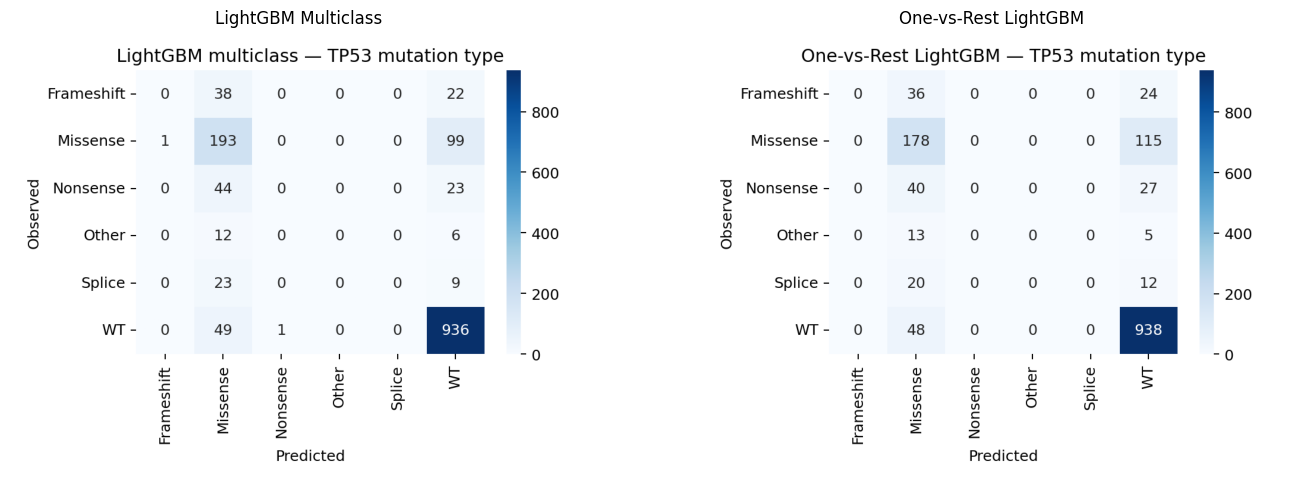

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, path, title in zip(axes,
    ['reports/figures/tcga_advanced_lgbm_confusion_matrix.png',
     'reports/figures/tcga_advanced_ovr_confusion_matrix.png'],
    ['LightGBM Multiclass', 'One-vs-Rest LightGBM']):
    ax.imshow(mpimg.imread(path))
    ax.axis('off')
    ax.set_title(title)
plt.tight_layout()
plt.show()

# Interpretation

This is a step backward from the baseline — the Linear SVM at least correctly identified some Frameshift (19), Nonsense (20), and Splice (5) samples. LightGBM predicts zero of these.

Why this happens:

Both models were trained on the top-3000 variable genes — a noisy, high-dimensional feature space where the minority class signal is buried. The baseline used curated p53 pathway genes (~50 genes) which concentrate the biologically relevant signal.
Despite class_weight='balanced', the WT class (6,571 training samples) so heavily dominates the feature landscape that LightGBM's splits consistently route minority class samples into the Missense or WT leaf nodes.
The OvR approach did not help — each binary classifier (e.g. "Splice vs rest") faces ~32 positive vs ~9,580 negative samples, and without per-estimator class weights the minority class is effectively ignored.
Conclusion: The confusion matrices confirm that model capacity was never the bottleneck here. The Linear SVM wins because its curated feature set acts as a biological prior, not because it is a more powerful learner.

## 5. Summary — TCGA vs CCLE

In [13]:
ccle_binary = pd.read_csv('reports/tables/binary_test_performance.csv')
ccle_mc     = pd.read_csv('reports/tables/multiclass_test_performance.csv')

summary = pd.DataFrame([
    {'dataset': 'CCLE', 'task': 'Binary',
     'best_model': f"{ccle_binary['model'].iloc[0]} / {ccle_binary['feature_set'].iloc[0]}",
     'key_metric': f"ROC-AUC: {ccle_binary['roc_auc'].iloc[0]:.3f}",
     'balanced_accuracy': ccle_binary['balanced_accuracy'].iloc[0],
     'f1_macro': ccle_binary['f1'].iloc[0]},
    {'dataset': 'TCGA', 'task': 'Binary',
     'best_model': f"{binary_test['model'].iloc[0]} / {binary_test['feature_set'].iloc[0]}",
     'key_metric': f"ROC-AUC: {binary_test['roc_auc'].iloc[0]:.3f}",
     'balanced_accuracy': binary_test['balanced_accuracy'].iloc[0],
     'f1_macro': binary_test['f1'].iloc[0]},
    {'dataset': 'CCLE', 'task': 'Multiclass',
     'best_model': f"{ccle_mc['model'].iloc[0]} / {ccle_mc['feature_set'].iloc[0]}",
     'key_metric': f"Macro F1: {ccle_mc['macro_f1'].iloc[0]:.3f}",
     'balanced_accuracy': ccle_mc['balanced_accuracy'].iloc[0],
     'f1_macro': ccle_mc['macro_f1'].iloc[0]},
    {'dataset': 'TCGA', 'task': 'Multiclass',
     'best_model': f"{mc_test['model'].iloc[0]} / {mc_test['feature_set'].iloc[0]}",
     'key_metric': f"Macro F1: {mc_test['macro_f1'].iloc[0]:.3f}",
     'balanced_accuracy': mc_test['balanced_accuracy'].iloc[0],
     'f1_macro': mc_test['macro_f1'].iloc[0]},
])
summary

,dataset,task,best_model,key_metric,balanced_accuracy,f1_macro
0,CCLE,Binary,random_forest / p53_pathway,ROC-AUC: 0.906,0.8119,0.8625
1,TCGA,Binary,hist_gradient_boosting / top_3000_variable,ROC-AUC: 0.921,0.8445,0.7894
2,CCLE,Multiclass,hist_gradient_boosting / tp53_targets,Macro F1: 0.467,0.4537,0.4668
3,TCGA,Multiclass,linear_svm / p53_pathway,Macro F1: 0.368,0.3834,0.3683


**Overall conclusions:**

1. **Binary task benefits from TCGA** — ROC-AUC improves from 0.906 to 0.921, confirming that more diverse tumor data provides a stronger transcriptional signal.
2. **Multiclass task is harder on TCGA** — macro F1 drops from 0.467 (CCLE) to 0.368 (TCGA). 
TCGA's additional classes (Splice, Other) and more severe class imbalance (WT=6,571 vs Other=121) make the problem harder despite more total data.
3. **Curated gene sets outperform genome-wide features for multiclass** — the p53 pathway genes (50 genes) beat top-3000 variable genes for LightGBM, showing biological priors are critical when signal is weak.
4. **More powerful models ≠ better results** — LightGBM and OvR underperformed the linear SVM baseline for multiclass, highlighting that model complexity is not the bottleneck here.
5. **The fundamental challenge remains** — mutation types share very similar transcriptional signatures since all disrupt p53 function. Expression alone may not be sufficient to reliably distinguish mutation mechanisms.